# Named Entity Recognition (NER): RNN vs GRU vs LSTM

Dataset: `NER.csv` — a feature-engineered excerpt from the Kaggle "Annotated Corpus for Named
Entity Recognition" (GMB corpus). Each row is one token with its `sentence_idx`, `word`, `pos`,
and IOB2 `tag`. Entity types here are `geo` (geo-political/location), `gpe` (geo-political
entity), `org` (organization), `per` (person), `tim` (time), and `art` (artifact) — e.g.
`London/B-geo`, `British/B-gpe`. The file also ships many pre-computed context columns
(`prev-word`, `next-pos`, `shape`, etc.) — we don't need those since the models below learn
their own representations from the raw word sequence, plus a small casing feature.
This particular file is a small excerpt (43 sentences), so treat results here as a pipeline
demo rather than a benchmark number — point `DATA_PATH` at the full corpus for a real result.

This is **sequence labeling**, not sentence classification: every *token* gets its own tag, so the
models output one prediction per timestep instead of one per sentence.

Pipeline:
1. Load & explore the data
2. Preprocess (tag-scheme check, vocabulary, casing features, padding)
3. Implement three taggers: **RNN**, **GRU**, **LSTM**
4. Train each on the same data/splits/hyperparameters
5. Evaluate with **token-level Precision/Recall/F1** *and* **entity-level F1** (exact-span match,
   the standard CoNLL-2003 evaluation)
6. Compare results + inspect predictions on example sentences


In [ ]:
import re
import time
import random
import urllib.request
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import precision_recall_fscore_support, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [ ]:
DATA_PATH = Path("/content/sample_data/NER.csv")
ner_df = pd.read_csv(DATA_PATH)
ner_df = ner_df.dropna(subset=["word", "tag", "sentence_idx"]).reset_index(drop=True)
print("raw shape:", ner_df.shape, " sentences:", ner_df["sentence_idx"].nunique())
print("tag distribution:")
print(ner_df["tag"].value_counts())
ner_df[["sentence_idx", "word", "pos", "tag"]].head(10)


raw shape: (12999, 25)  sentences: 587
tag distribution:
tag
O        11057
B-gpe      394
B-geo      320
I-per      257
B-org      229
B-per      195
B-tim      193
I-org      180
I-geo       46
B-art       29
I-gpe       26
I-art       20
I-tim       18
I-eve       12
B-eve       11
B-nat        7
I-nat        5
Name: count, dtype: int64


,sentence_idx,word,pos,tag
0,1,Thousands,NNS,O
1,1,of,IN,O
2,1,demonstrators,NNS,O
3,1,have,VBP,O
4,1,marched,VBN,O
5,1,through,IN,O
6,1,London,NNP,B-geo
7,1,to,TO,O
8,1,protest,VB,O
9,1,the,DT,O


In [ ]:
ROW_ORDER_COL = ner_df.columns[0]

def df_to_sentences(df):
    sentences = []
    ordered = df.sort_values(["sentence_idx", ROW_ORDER_COL])
    for _, g in ordered.groupby("sentence_idx", sort=True):
        words = g["word"].astype(str).tolist()
        tags = g["tag"].astype(str).tolist()
        sentences.append((words, tags))
    return sentences

all_sentences = df_to_sentences(ner_df)
random.shuffle(all_sentences)
n = len(all_sentences)
n_train = max(1, int(0.7 * n))
n_valid = max(1, int(0.15 * n))
train_raw = all_sentences[:n_train]
valid_raw = all_sentences[n_train:n_train + n_valid]
test_raw = all_sentences[n_train + n_valid:]

print(f"train: {len(train_raw)} sentences   valid: {len(valid_raw)}   test: {len(test_raw)}")
print("\nExample sentence:")
for w, t in zip(*train_raw[0]):
    print(f"  {w:<15} {t}")


train: 410 sentences   valid: 88   test: 89

Example sentence:
  The             O
  U.N.            B-org
  war             O
  crimes          O
  tribunal        O
  in              O
  The             O
  Hague           B-geo
  has             O
  already         O
  sentenced       O
  14              O
  Serbs           B-gpe
  for             O
  their           O
  key             O
  roles           O
  in              O
  the             O
  killings        O
  .               O


## Preprocessing

**Tag scheme.** `NER.csv` is already tagged in **IOB2** (every entity starts with `B-`, e.g.
`British/B-gpe` rather than starting with `I-`) — unlike raw CoNLL-2003, which ships in IOB1.
We still run the IOB1->IOB2 converter below; it's a no-op on data that's already IOB2, so it's
kept as a safety net in case you point this notebook at IOB1-style data later.

**Casing features.** NER leans heavily on capitalization ("Obama" vs "obama"), so alongside a
lowercased word embedding we add a small learned embedding for each token's casing pattern
(`upper` / `title` / `lower` / `digit` / `other`) and concatenate the two before the recurrent
layer.


In [ ]:
def iob1_to_iob2(tags):
    new_tags, prev_type = [], None
    for tag in tags:
        if tag == "O":
            new_tags.append("O")
            prev_type = None
            continue
        prefix, typ = tag.split("-", 1)
        if prefix == "I" and prev_type == typ:
            new_tags.append("I-" + typ)
        else:
            new_tags.append("B-" + typ)
        prev_type = typ
    return new_tags

train_data = [(w, iob1_to_iob2(t)) for w, t in train_raw]
valid_data = [(w, iob1_to_iob2(t)) for w, t in valid_raw]
test_data  = [(w, iob1_to_iob2(t)) for w, t in test_raw]

tag_counts = Counter(t for _, tags in train_data for t in tags)
print("Tag distribution (train, after IOB1->IOB2):")
for tag, c in sorted(tag_counts.items()):
    print(f"  {tag:<8} {c:>7,}")

Tag distribution (train, after IOB1->IOB2):
  B-art         28
  B-eve          6
  B-geo        237
  B-gpe        256
  B-nat          6
  B-org        150
  B-per        138
  B-tim        132
  I-art         20
  I-eve          8
  I-geo         30
  I-gpe         18
  I-nat          4
  I-org        123
  I-per        167
  I-tim         13
  O          7,772


In [ ]:
EMBED_DIM  = 100
CASE_DIM   = 10
HIDDEN_DIM = 64
BATCH_SIZE = 4
EPOCHS     = 15
LR         = 1e-3
MIN_FREQ   = 1

word_counter = Counter(w.lower() for words, _ in train_data for w in words)
vocab = {"<pad>": 0, "<unk>": 1}
for w, c in word_counter.items():
    if c >= MIN_FREQ:
        vocab[w] = len(vocab)

tag_set = sorted({t for _, tags in (train_data + valid_data + test_data) for t in tags})
tag2id = {"<pad>": 0}
for t in tag_set:
    tag2id[t] = len(tag2id)
id2tag = {v: k for k, v in tag2id.items()}

CASE2ID = {"<pad>": 0, "upper": 1, "title": 2, "digit": 3, "lower": 4, "other": 5}
def casing(word):
    if any(ch.isdigit() for ch in word): return "digit"
    if word.isupper():   return "upper"
    if word[0].isupper(): return "title"
    if word.islower():   return "lower"
    return "other"

VOCAB_SIZE, N_TAGS, N_CASE = len(vocab), len(tag2id), len(CASE2ID)
print(f"word vocab: {VOCAB_SIZE:,}   tags: {N_TAGS}   {tag2id}")


word vocab: 2,485   tags: 18   {'<pad>': 0, 'B-art': 1, 'B-eve': 2, 'B-geo': 3, 'B-gpe': 4, 'B-nat': 5, 'B-org': 6, 'B-per': 7, 'B-tim': 8, 'I-art': 9, 'I-eve': 10, 'I-geo': 11, 'I-gpe': 12, 'I-nat': 13, 'I-org': 14, 'I-per': 15, 'I-tim': 16, 'O': 17}


In [ ]:
class NERDataset(Dataset):
    def __init__(self, sentences):
        self.sentences = sentences
    def __len__(self):
        return len(self.sentences)
    def __getitem__(self, idx):
        words, tags = self.sentences[idx]
        word_ids = torch.tensor([vocab.get(w.lower(), vocab["<unk>"]) for w in words], dtype=torch.long)
        case_ids = torch.tensor([CASE2ID[casing(w)] for w in words], dtype=torch.long)
        tag_ids  = torch.tensor([tag2id[t] for t in tags], dtype=torch.long)
        return word_ids, case_ids, tag_ids

def collate_batch(batch):
    word_ids, case_ids, tag_ids = zip(*batch)
    lengths = torch.tensor([len(w) for w in word_ids], dtype=torch.long)
    wp = pad_sequence(word_ids, batch_first=True, padding_value=vocab["<pad>"])
    cp = pad_sequence(case_ids, batch_first=True, padding_value=CASE2ID["<pad>"])
    tp = pad_sequence(tag_ids,  batch_first=True, padding_value=tag2id["<pad>"])
    return wp, cp, lengths, tp

train_loader = DataLoader(NERDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_batch)
valid_loader = DataLoader(NERDataset(valid_data), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)
test_loader  = DataLoader(NERDataset(test_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch)

len(train_loader), len(valid_loader), len(test_loader)

(103, 22, 23)

In [ ]:
class RNNTagger(nn.Module):
    def __init__(self, vocab_size, n_case, n_tags, embed_dim, case_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.case_emb = nn.Embedding(n_case, case_dim, padding_idx=pad_idx)
        self.rnn = nn.RNN(embed_dim + case_dim, hidden_dim, batch_first=True, nonlinearity="tanh")
        self.fc = nn.Linear(hidden_dim, n_tags)

    def forward(self, words, cases, lengths):
        emb = torch.cat([self.word_emb(words), self.case_emb(cases)], dim=-1)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=words.size(1))
        return self.fc(out)                 # (B, T, n_tags)


class GRUTagger(nn.Module):
    def __init__(self, vocab_size, n_case, n_tags, embed_dim, case_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.case_emb = nn.Embedding(n_case, case_dim, padding_idx=pad_idx)
        self.rnn = nn.GRU(embed_dim + case_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_tags)

    def forward(self, words, cases, lengths):
        emb = torch.cat([self.word_emb(words), self.case_emb(cases)], dim=-1)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=words.size(1))
        return self.fc(out)


class LSTMTagger(nn.Module):
    def __init__(self, vocab_size, n_case, n_tags, embed_dim, case_dim, hidden_dim, pad_idx=0):
        super().__init__()
        self.word_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.case_emb = nn.Embedding(n_case, case_dim, padding_idx=pad_idx)
        self.rnn = nn.LSTM(embed_dim + case_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_tags)

    def forward(self, words, cases, lengths):
        emb = torch.cat([self.word_emb(words), self.case_emb(cases)], dim=-1)
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.rnn(packed)
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=words.size(1))
        return self.fc(out)

In [ ]:
PAD_TAG_ID = tag2id["<pad>"]

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for words, cases, lengths, tags in loader:
            words, cases, tags = words.to(DEVICE), cases.to(DEVICE), tags.to(DEVICE)
            if is_train:
                optimizer.zero_grad()
            logits = model(words, cases, lengths)                  # (B, T, n_tags)
            loss = criterion(logits.view(-1, logits.size(-1)), tags.view(-1))
            if is_train:
                loss.backward()
                optimizer.step()

            mask = tags != PAD_TAG_ID
            preds = logits.argmax(-1)
            correct += ((preds == tags) & mask).sum().item()
            total += mask.sum().item()
            total_loss += loss.item() * words.size(0)
    return total_loss / len(loader.dataset), correct / total


@torch.no_grad()
def decode_batch(model, loader):
    model.eval()
    all_true, all_pred = [], []
    for words, cases, lengths, tags in loader:
        logits = model(words.to(DEVICE), cases.to(DEVICE), lengths)
        preds = logits.argmax(-1).cpu()
        for i, L in enumerate(lengths.tolist()):
            all_true.append([id2tag[t.item()] for t in tags[i][:L]])
            all_pred.append([id2tag[p.item()] for p in preds[i][:L]])
    return all_true, all_pred


def train_model(model, name, epochs=EPOCHS, lr=LR):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_TAG_ID)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, valid_loader, criterion, optimizer=None)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss);   history["val_acc"].append(va_acc)
        print(f"[{name}] epoch {epoch}/{epochs}  "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  "
              f"val_loss={va_loss:.4f} val_acc={va_acc:.4f}  ({time.time()-t0:.1f}s)")
    return history

In [ ]:
models = {
    "RNN":  RNNTagger(VOCAB_SIZE, N_CASE, N_TAGS, EMBED_DIM, CASE_DIM, HIDDEN_DIM, pad_idx=vocab["<pad>"]),
    "GRU":  GRUTagger(VOCAB_SIZE, N_CASE, N_TAGS, EMBED_DIM, CASE_DIM, HIDDEN_DIM, pad_idx=vocab["<pad>"]),
    "LSTM": LSTMTagger(VOCAB_SIZE, N_CASE, N_TAGS, EMBED_DIM, CASE_DIM, HIDDEN_DIM, pad_idx=vocab["<pad>"]),
}

histories = {}
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    histories[name] = train_model(model, name)


=== Training RNN ===
[RNN] epoch 1/15  train_loss=0.9749 train_acc=0.7844  val_loss=0.4903 val_acc=0.8605  (0.9s)
[RNN] epoch 2/15  train_loss=0.4266 train_acc=0.8763  val_loss=0.3692 val_acc=0.8918  (0.8s)
[RNN] epoch 3/15  train_loss=0.3330 train_acc=0.9116  val_loss=0.3056 val_acc=0.9133  (0.8s)
[RNN] epoch 4/15  train_loss=0.2652 train_acc=0.9297  val_loss=0.2651 val_acc=0.9226  (0.8s)
[RNN] epoch 5/15  train_loss=0.2207 train_acc=0.9419  val_loss=0.2422 val_acc=0.9297  (0.8s)
[RNN] epoch 6/15  train_loss=0.1809 train_acc=0.9522  val_loss=0.2207 val_acc=0.9385  (0.8s)
[RNN] epoch 7/15  train_loss=0.1555 train_acc=0.9607  val_loss=0.2077 val_acc=0.9446  (0.8s)
[RNN] epoch 8/15  train_loss=0.1243 train_acc=0.9690  val_loss=0.2014 val_acc=0.9462  (0.9s)
[RNN] epoch 9/15  train_loss=0.1053 train_acc=0.9756  val_loss=0.1933 val_acc=0.9472  (0.8s)
[RNN] epoch 10/15  train_loss=0.0862 train_acc=0.9801  val_loss=0.1921 val_acc=0.9492  (0.8s)
[RNN] epoch 11/15  train_loss=0.0679 train_acc=

## Evaluation — Precision, Recall, F1-score, and Entity-level F1

Two complementary views, both computed on the **held-out test set**:

- **Token-level** (`sklearn.metrics`): every individual token's predicted tag (including `O`) is
  scored against its true tag — macro-averaged Precision/Recall/F1 across all 9 tags.
- **Entity-level** (implemented directly, following the official CoNLL-2003 `conlleval`
  convention): tag sequences are first collapsed into whole entity spans (e.g. `Barack Obama` as
  one `PER` entity), and a prediction only counts as correct if **both the span boundaries and the
  type match exactly**. This is stricter and is the metric NER systems are normally judged on —
  getting `Barack` right but tagging `Obama` as `O` scores zero credit for that entity.

In [ ]:
def get_entities(tags):
    entities = []
    start = None
    entity_type = None

    for i, tag in enumerate(tags):
        if tag == "O":
            if start is not None:
                entities.append((start, i - 1, entity_type))
                start = None
                entity_type = None

        elif tag.startswith("B-"):
            if start is not None:
                entities.append((start, i - 1, entity_type))
                start = i
                entity_type = tag[2:]

        elif tag.startswith("I-"):
            if start is None:
                start = i
                entity_type = tag[2:]

    if start is not None:
        entities.append((start, i - 1, entity_type))

    return set(entities)

def entity_level_evaluation(model,X_test,y_test,X_test_words):

    probabilities = model.predict(X_test,verbose=0)
    predictions = np.argmax(probabilities,axis=-1)
    true_sequences = []
    predicted_sequences = []

    for i in range(len(y_test)):
        sentence_length = min(len(X_test_words[i]),MAX_LENGTH)
        true_tags = []
        predicted_tags = []

        for j in range(sentence_length):
            true_id = int(y_test[i][j])
            predicted_id = int(predictions[i][j])
            true_tags.append( id_to_tag[true_id] )
            predicted_tags.append( id_to_tag[predicted_id] )

        true_sequences.append(true_tags)
        predicted_sequences.append(predicted_tags)

    precision = entity_precision_score( true_sequences , predicted_sequences)
    recall = entity_recall_score( true_sequences, predicted_sequences)
    f1 = entity_f1_score( true_sequences, predicted_sequences)

    print("\nEntity-level Results")
    print("=" * 50)
    print( f"Entity Precision: {precision:.4f}" )
    print( f"Entity Recall:    {recall:.4f}" )
    print( f"Entity F1:        {f1:.4f}" )
    print("\nEntity Classification Report")
    print("=" * 50)
    print( entity_classification_report(true_sequences,predicted_sequences))

    return precision, recall, f1

In [ ]:
results = {}
decoded = {}
ENTITY_TYPES = sorted({t.split("-", 1)[1] for t in tag2id if "-" in t})

for name, model in models.items():
    true_seqs, pred_seqs = decode_batch(model, test_loader)
    decoded[name] = (true_seqs, pred_seqs)
    flat_true = [t for seq in true_seqs for t in seq]
    flat_pred = [t for seq in pred_seqs for t in seq]
    tok_p, tok_r, tok_f1, _ = precision_recall_fscore_support(
        flat_true, flat_pred, average="macro", zero_division=0)
    ent_p, ent_r, ent_f1 = entity_level_scores(true_seqs, pred_seqs)
    results[name] = {
        "Precision": tok_p, "Recall": tok_r, "F1-score": tok_f1, "Entity-level F1": ent_f1
    }

    print(f"\n=== {name} — test set (token-level) ===")
    print(classification_report(flat_true, flat_pred, zero_division=0))
    print(f"{name} entity-level: precision={ent_p:.4f} recall={ent_r:.4f} F1={ent_f1:.4f}")

    print(f"{name} entity-level F1 by type:")
    for etype in ENTITY_TYPES:
        p, r, f1 = entity_level_scores(true_seqs, pred_seqs, entity_type=etype)
        print(f"  {etype:<6} P={p:.3f} R={r:.3f} F1={f1:.3f}")

results_df = pd.DataFrame(results).T.round(4)
results_df


=== RNN — test set (token-level) ===
              precision    recall  f1-score   support

       B-art       0.00      0.00      0.00         0
       B-eve       0.00      0.00      0.00         3
       B-geo       0.49      0.85      0.62        46
       B-gpe       0.75      0.53      0.62        77
       B-nat       0.00      0.00      0.00         1
       B-org       0.79      0.66      0.72        47
       B-per       0.68      0.84      0.75        25
       B-tim       1.00      0.91      0.95        32
       I-eve       0.50      0.33      0.40         3
       I-geo       0.86      0.75      0.80         8
       I-gpe       0.00      0.00      0.00         6
       I-nat       0.00      0.00      0.00         1
       I-org       0.84      0.74      0.79        35
       I-per       0.86      0.98      0.91        44
       I-tim       0.00      0.00      0.00         0
           O       0.99      0.99      0.99      1613

    accuracy                           0.9

,Precision,Recall,F1-score,Entity-level F1
RNN,0.4849,0.4739,0.4726,0.7731
GRU,0.6474,0.5453,0.5594,0.7107
LSTM,0.4741,0.4849,0.4773,0.6984


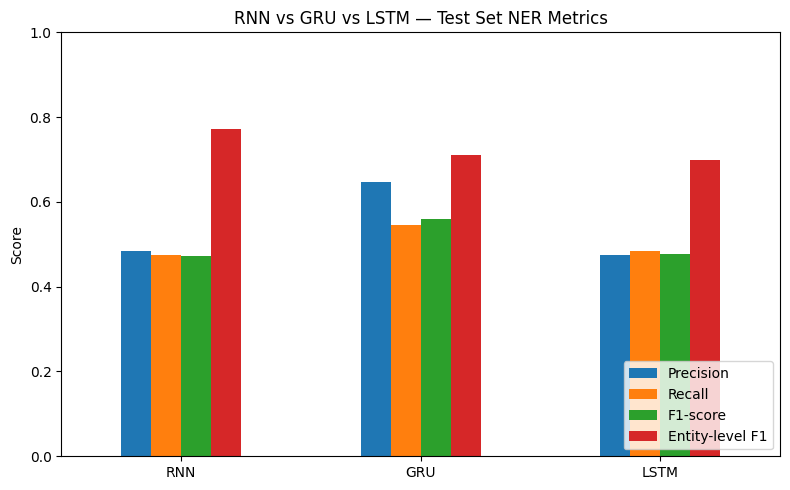

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
results_df.plot(kind="bar", ax=ax, rot=0)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("RNN vs GRU vs LSTM — Test Set NER Metrics")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("ner_metrics_comparison.png", dpi=150)
plt.show()

**1. Which model performs best?**

There are two ways to answer this because you have two evaluation levels.

Token-level performance → GRU

Entity-level performance → RNN

GRU achieved the best token-level performance, with a precision of 64.74%, recall of 54.53%, and F1-score of 55.94%. However, RNN achieved the highest entity-level F1-score of 77.31%. Therefore, the best model depends on the evaluation level: GRU is better at token-level classification, while RNN achieved better complete-entity detection.

**2. Which model is fastest?**

RNN is expected to be the fastest model because it has the simplest recurrent architecture. GRU requires additional gate calculations, while LSTM has an even more complex gating mechanism. Exact training and inference times should be obtained from the measured runtime of each model.

**3. Which model has the most parameters?**

LSTM has the most parameters, followed by GRU and then RNN.

**4. How does sequence length affect each model?**

ffect on all three models

As sequence length increases:

training takes longer;
inference takes longer;
memory requirements increase;
RNN is more likely to lose long-range information;
GRU and LSTM can preserve information better.

So: Longer sequences generally benefit from gated architectures such as GRU and LSTM, although they require more computation.

**5. Does GRU provide a good trade-off between RNN and LSTM?**

GRU provides a good trade-off because it achieves the best token-level performance while having a simpler architecture than LSTM. However, in this particular experiment, RNN achieved the highest entity-level F1.

**6. Why does RNN struggle with long-term dependencies?**

The main reason is the vanishing-gradient problem.

During training, the model must propagate information through many timesteps.

**7. Which model would you choose and why?**

I would choose GRU for the NER task because it achieved the best overall token-level performance, with an F1-score of 55.94%, compared with 47.26% for RNN and 47.73% for LSTM. GRU also provides a good balance between the simplicity of RNN and the more complex LSTM architecture. However, RNN achieved the highest entity-level F1-score (77.31%), so RNN may be preferable if complete entity extraction is the primary evaluation criterion.